## Loading dataset

In [1]:
!unzip MC3_release.zip

Archive:  MC3_release.zip
   creating: MC3_release/
  inflating: MC3_release/MC3_data_description.pdf  
  inflating: MC3_release/MC3_graph.json  
  inflating: MC3_release/MC3_schema.json  
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet.htm  
   creating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/colorschememapping.xml  
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/filelist.xml  
  inflating: MC3_release/VAST Challenge 2025 C3 Answer Sheet_files/themedata.thmx  


In [2]:
%cd MC3_release

/content/MC3_release


In [3]:
import networkx as nx
import json
import pandas as pd
import os
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn

In [98]:
with open('MC3_graph.json', 'r') as f: json_data = json.load(f)
G = nx.node_link_graph(json_data, edges="edges")

## Nodes inspection

In [5]:
from IPython.display import display
display(pd.DataFrame([{'type':G.nodes[v]['type'], 'sub_type':G.nodes[v]['sub_type']} for v in G.nodes()]).value_counts().sort_index())

type          sub_type        
Entity        Group                 5
              Location             29
              Organization          5
              Person               18
              Vessel               15
Event         Assessment           36
              Collaborate          25
              Communication       584
              Criticize             1
              Enforcement          21
              Fishing               1
              HarborReport          2
              Monitoring           70
              TourActivity         13
              TransponderPing       3
              VesselMovement       46
Relationship  AccessPermission     68
              Colleagues           30
              Coordinates          74
              Friends               2
              Jurisdiction         13
              Operates             40
              Reports              25
              Suspicious           28
              Unfriendly            5
Name: count, dtype: int64

### Mini-goals of this work
- Find where there is information using conversation topics.
- Identify communication networks.
- Find where there is information using pseudonyms.

Now we just make neste dicts for easier data handling

In [6]:
map_nodes = {}
nested_info = {}
for v in G.nodes():
  map_nodes[G.nodes[v]['label']] = G.nodes[v]['type']
  if G.nodes[v]['type'] not in nested_info:
      nested_info[G.nodes[v]['type']] = {G.nodes[v]['sub_type']:[G.nodes[v]]}
      continue
  if G.nodes[v]['sub_type'] not in nested_info[G.nodes[v]['type']]:
      nested_info[G.nodes[v]['type']][G.nodes[v]['sub_type']] = [G.nodes[v]]
      continue
  nested_info[G.nodes[v]['type']][G.nodes[v]['sub_type']].append(G.nodes[v])


## Distribution of sub types by each node type identified by Clepper Jessen

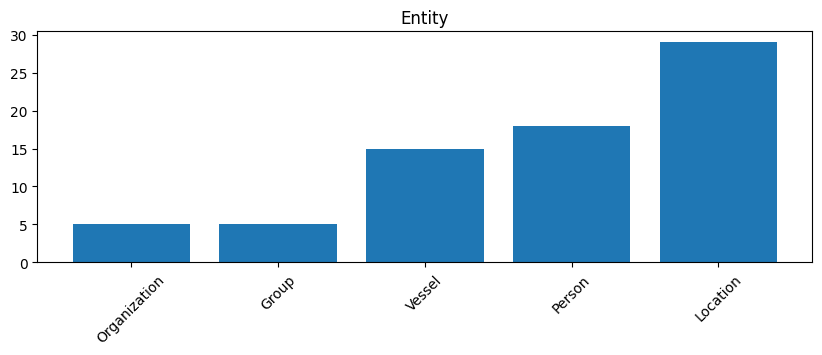

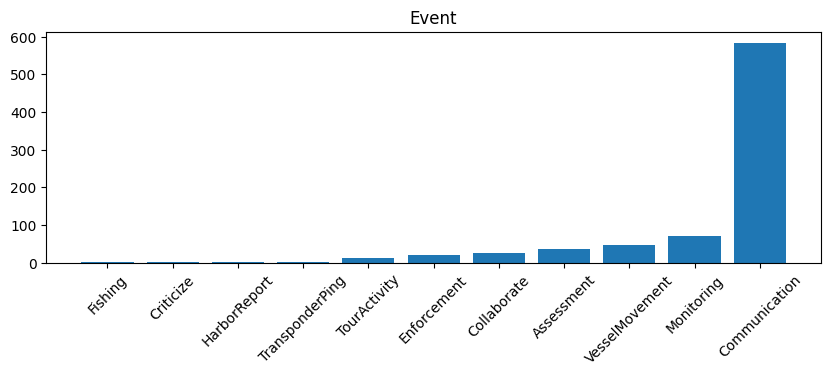

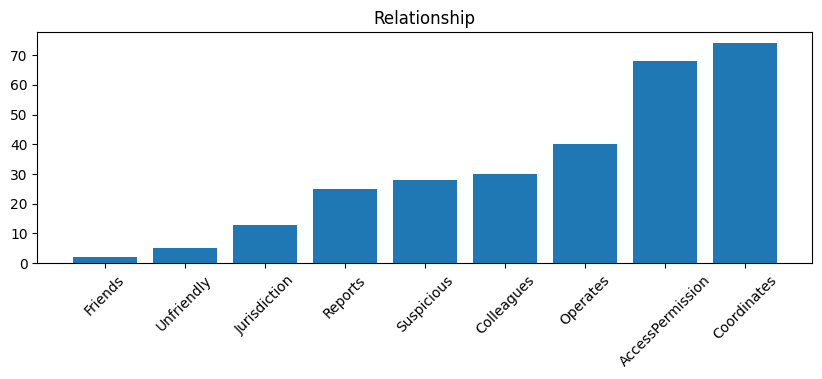

In [7]:
attr = [(k,[(ki,len(vi)) for ki, vi in nested_info[k].items()]) for k,v in nested_info.items()]
for type_node, attr_i in attr:
    tmp_i = attr_i.copy()
    tmp_i.sort(key=lambda x: x[1])
    plt.figure(figsize=(10, 3))
    labels = [k for k,v in tmp_i]
    heights = [v for k,v in tmp_i]
    plt.bar(labels, heights)
    plt.title(type_node)
    plt.xticks(rotation=45)
    plt.show()
    plt.close()

## Inspection by type

In [8]:
def beauty_print(dict_info):
    for k,v in dict_info.items():
        print(f'{k} - {v}')
    print('\n')
# beauty_print(nested_info['Entity']['Person'][0])
# beauty_print(nested_info['Event']['Communication'][0])
# beauty_print(nested_info['Relationship']['AccessPermission'][0])
display(pd.Series(nested_info['Entity']['Person'][0], name="Entity"))
display(pd.Series(nested_info['Event']['Communication'][0], name="Event"))
display(pd.Series(nested_info['Relationship']['AccessPermission'][0], name="Relationship"))

,Entity
type,Entity
label,Sam
name,Sam
sub_type,Person


,Event
type,Event
sub_type,Communication
label,Communication
timestamp,2040-10-01 08:09:00
content,"Hey The Intern, it's The Lookout! Just spotted..."


,Relationship
type,Relationship
sub_type,AccessPermission
label,AccessPermission
permission_type,restricted
start_date,None
end_date,None


In [9]:
labels_info = {}
for i_type, i_nodes in nested_info.items():
    labels_info[i_type] = {}
# for i in nested_info['Event'].keys():
    print(f"{'\n'*2} Analysis of {i_type} {30*'='}")
    for j_subtypes, j_nodes in i_nodes.items():
        labels_info[i_type][j_subtypes] = {}
        tmp = pd.Series(
            [k for info in j_nodes for k in info.keys()], name=f'Analysis of {j_subtypes}'
            ).value_counts()

        display(pd.DataFrame(tmp).T)
        labels_info[i_type][j_subtypes] = list(tmp.keys())
        # break
    # break



 Analysis of Entity ==============================


Analysis of Person,type,label,name,sub_type
count,18,18,18,18


Analysis of Organization,type,label,name,sub_type
count,5,5,5,5


Analysis of Vessel,type,label,name,sub_type
count,15,15,15,15


Analysis of Group,type,label,name,sub_type
count,5,5,5,5


...

Analysis of Jurisdiction,type,sub_type,label,jurisdiction_type,authority_level
count,13,13,13,13,13


Analysis of Coordinates,type,sub_type,label,coordination_type,start_date
count,74,74,74,74,74


Analysis of Operates,type,sub_type,label,start_date,operational_role
count,40,40,40,40,40


Analysis of Suspicious,type,sub_type,label
count,28,28,28


Analysis of Unfriendly,type,sub_type,label
count,5,5,5


In [10]:
e_info = [{
    'u_source': u, 'u_type': G.nodes[u]['type'], 'u_subtype':G.nodes[u]['sub_type'],
    'v_target':v, 'v_type': G.nodes[v]['type'], 'v_subtype':G.nodes[v]['sub_type'],
    'is_inferred':G[u][v]['is_inferred']} for (u, v) in G.edges()]

tmp = pd.DataFrame(e_info)

In [11]:
display(tmp[(tmp['u_subtype'] == 'Communication') & (tmp['v_type'] == 'Entity')]['is_inferred'].value_counts())
display(tmp[(tmp['v_subtype'] == 'Communication') & (tmp['u_type'] == 'Entity')]['is_inferred'].value_counts())

display(
    pd.DataFrame(
    tmp[(tmp['u_subtype'] == 'Communication')][['v_subtype', 'is_inferred']].value_counts().sort_index()
    ).reset_index().sort_values(by=['is_inferred'])
    )

# display(tmp[(tmp['v_subtype'] == 'Communication') & (tmp['u_type'] == 'Entity')]['is_inferred'].value_counts())
# tmp[(tmp['u_subtype'] == 'Communication') & (tmp['v_type'] == 'Entity') & (tmp['is_inferred'] == False)]

,count
is_inferred,
False,584


,count
is_inferred,
False,584


,v_subtype,is_inferred,count
16,Person,False,201
15,Organization,False,98
9,Group,False,1
22,Vessel,False,247
12,Location,False,37
0,AccessPermission,True,151
21,Unfriendly,True,6
20,TransponderPing,True,9
19,TourActivity,True,20
18,Suspicious,True,38


In [99]:
nodes, edges = G.nodes(), G.edges()
entities = pd.DataFrame([nodes[i] for i in nodes if 'Entity' in nodes[i]['type']])
communications = pd.DataFrame([nodes[i] for i in nodes if 'Communication' in nodes[i]['sub_type']])
messages = pd.DataFrame([
    {'src':u,'tgt':v}
    for u, v in edges
    if ('Entity' in nodes[u]['type'] and 'Communication' in nodes[v]['sub_type'])
    or ('Entity' in nodes[v]['type'] and 'Communication' in nodes[u]['sub_type'])
    ])

In [100]:
# conversations = pd.DataFrame(0, index=entities['label'].tolist(), columns=entities['label'].tolist())
conversations = []
for i_dx, i_row in entities.iterrows():
    src = i_row['label']
    nbgs = G[src]
    for comm, comm_attr in nbgs.items():
        if 'Communication' not in nodes[comm]['sub_type']:
            continue
        for tgt, tgt_attr in G[comm].items():
            if 'Entity' not in nodes[tgt]['type']:
                continue
            conversations.append({'src': src, 'tgt': tgt, 'comm': comm, 'content':nodes[comm]['content'], 'timestamp':nodes[comm]['timestamp']})
conversations = pd.DataFrame(conversations)

In [87]:
conversations[['src', 'tgt']].value_counts()

src                 tgt                 
Clepper Jensen      Miranda Jordan          20
Miranda Jordan      Clepper Jensen          18
The Intern          Mrs. Money              15
Green Guardians     Oceanus City Council    12
                    Green Guardians         12
                                            ..
V. Miesel Shipping  Elise                    1
                    Nadia Conti              1
                    Mrs. Money               1
                    Mako                     1
                    Rodriguez                1
Name: count, Length: 217, dtype: int64

In [88]:
conversations

,src,tgt,comm,content,timestamp
0,Sam,Kelly,Event_Communication_370,"Hey Kelly, it's Sam. This permit approval seem...",2040-10-05 10:48:00
1,Kelly,Sam,Event_Communication_3,"Sam, it's Kelly! Let's meet at Sunrise Point a...",2040-10-01 08:13:00
2,Kelly,Sam,Event_Communication_443,"Hey Sam, it's Kelly! Got some photos of those ...",2040-10-07 08:11:00
3,Nadia Conti,Haacklee Harbor,Event_Communication_331,"Haacklee Harbor, this is Nadia Conti. I need t...",2040-10-05 09:45:00
4,Nadia Conti,Oceanus City Council,Event_Communication_334,This is Nadia Conti. My cancellation was due t...,2040-10-05 09:49:00
...,...,...,...,...,...
579,Himark Harbor,Oceanus City Council,Event_Communication_696,Himark Harbor to Oceanus City Council. Officia...,2040-10-10 12:22:00
580,Himark Harbor,Seawatch,Event_Communication_785,Himark Harbor to Seawatch. Reminder that Nemo ...,2040-10-11 10:44:00
581,Himark Harbor,Seawatch,Event_Communication_789,Himark Harbor to Seawatch. Your report of vess...,2040-10-11 10:49:00
582,Himark Harbor,Neptune,Event_Communication_890,Himark Harbor to Neptune. Your personnel trans...,2040-10-13 11:48:00


## Conversation Graph

In [101]:
G_messages = nx.DiGraph()

for _, row in conversations.iterrows():

    src = row["src"]
    tgt = row["tgt"]

    if G_messages.has_edge(src, tgt):
        G_messages[src][tgt]["weight"] += 1
    else:
        G_messages.add_edge(src, tgt, weight=1)

In [102]:
pagerank = nx.pagerank(G_messages)
indegree = dict(G_messages.in_degree())
outdegree = dict(G_messages.out_degree())
betweenness = nx.betweenness_centrality(G_messages)
clustering = nx.clustering(G_messages.to_undirected())

In [107]:
interaction_matrix = pd.DataFrame(
    0,
    index=entities['label'].tolist(),
    columns=entities['label'].tolist()
)

for src, tgt, data in G_messages.edges(data=True):
    interaction_matrix.loc[src, tgt] = data["weight"]

In [124]:
from sklearn.metrics.pairwise import cosine_similarity

structural_similarity = cosine_similarity(interaction_matrix)

structural_similarity_df = pd.DataFrame(
    structural_similarity,
    index=entities['label'].tolist(),
    columns=entities['label'].tolist()
)

In [312]:
from sentence_transformers import SentenceTransformer
from datetime import datetime
from collections import defaultdict

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

entity_messages = defaultdict(list)

for _, row in conversations.iterrows():
    entity_messages[row["src"]].append(
        row["content"]
    )

entity_embeddings = {}

for entity, msgs in entity_messages.items():

    if len(msgs) == 0:
        continue

    embeddings = model.encode(msgs)

    entity_embeddings[entity] = embeddings
    # entity_embeddings[entity] = np.mean(embeddings, axis=0)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [316]:
tmp_embeddings = entity_embeddings.copy()
entity_embeddings = {entity: np.mean(emb, axis=0) for entity, emb in entity_embeddings.items()}

## Semantic analysis

In [317]:
semantic_vectors = []

for entity in entities['label'].tolist():

    if entity in entity_embeddings:
        semantic_vectors.append(
            entity_embeddings[entity]
        )
    else:
        semantic_vectors.append(
            np.zeros(384)
        )

semantic_similarity = cosine_similarity(
    semantic_vectors
)

semantic_similarity_df = pd.DataFrame(
    semantic_similarity,
    index=entities['label'].tolist(),
    columns=entities['label'].tolist()
)

In [320]:
from umap import UMAP

proj_embeddings = np.array([v for k,v in entity_embeddings.items()])

umap = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = umap.fit_transform(proj_embeddings)

print("Shape:", embedding.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape: (39, 2)


In [202]:
dict_proj_embeddings = {k:embedding[i].tolist() for i, (k,v) in enumerate(entity_embeddings.items())}
with open('semantic_projection.json', 'w') as f: json.dump(dict_proj_embeddings, f)

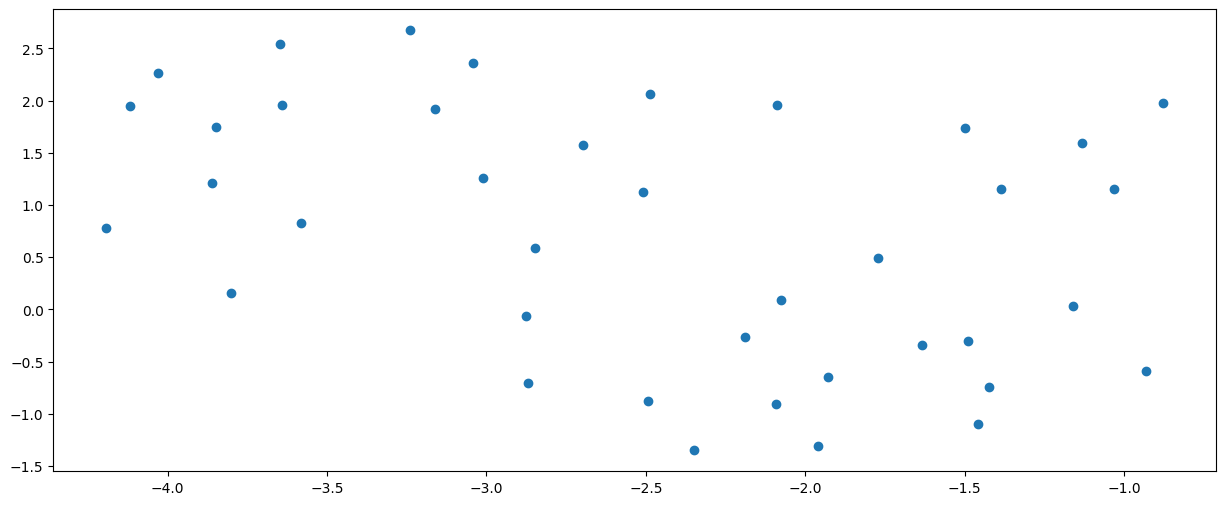

In [321]:
proj_df = pd.DataFrame([{'Entity': k, 'x':v[0], 'y':v[1]} for k,v in dict_proj_embeddings.items()])
plt.figure(figsize=(15, 6))
plt.scatter(proj_df['x'], proj_df['y'])
plt.show()

## Semantic Retrieval

In [322]:
# pip install sentence-transformers bertopic umap-learn hdbscan scikit-learn
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.9 MB/s eta 0:00:00


In [323]:
# pip install sentence-transformers bertopic umap-learn hdbscan scikit-learn

from collections import defaultdict

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer


entity_messages = defaultdict(list)

for _, row in conversations.iterrows():
    msg = str(row["content"]).strip()

    if len(msg) == 0:
        continue

    entity_messages[row["src"]].append(msg)

all_messages = []
message_entities = []

for entity, msgs in entity_messages.items():
    for msg in msgs:
        all_messages.append(msg)
        message_entities.append(entity)

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    all_messages,
    normalize_embeddings=True,
    show_progress_bar=True
)

umap_model = UMAP(
    n_neighbors=30,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=2,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    embedding_model=model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)


topics, probs = topic_model.fit_transform(
    all_messages,
    embeddings
)

topic_info = topic_model.get_topic_info()

print(topic_info.head(20))

for topic_id in topic_info.Topic.tolist():

    if topic_id == -1:
        continue

    print(f"\n=== TOPIC {topic_id} ===")

    words = topic_model.get_topic(topic_id)

    for word, score in words[:10]:
        print(f"{word:<20} {score:.4f}")


messages_df = pd.DataFrame({
    "entity": message_entities,
    "message": all_messages,
    "topic": topics
})

print(messages_df.head())


# ============================================================
# 10. ENTIDADES MAS ASOCIADAS A CADA TOPICO
# ============================================================

topic_entity_counts = (
    messages_df
    .groupby(["topic", "entity"])
    .size()
    .reset_index(name="count")
    .sort_values(["topic", "count"], ascending=[True, False])
)

print(topic_entity_counts.head(30))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

2026-05-04 21:50:10,977 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 21:50:12,936 - BERTopic - Dimensionality - Completed ✓
2026-05-04 21:50:12,937 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 21:50:13,006 - BERTopic - Cluster - Completed ✓
2026-05-04 21:50:13,015 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 21:50:13,085 - BERTopic - Representation - Completed ✓


    Topic  Count                                             Name  \
0      -1    163                      -1_reef_nemo_nemo reef_mako   
1       0     66                 0_remora_neptune_miesel_security   
2       1     54         1_city council_oceanus_oceanus city_city   
3       2     51              2_himark harbor_himark_harbor_berth   
4       3     45        3_green guardians_guardians_horizon_green   
5       4     33       4_lookout_intern_birdwatching_conservation   
6       5     32      5_paackland harbor_paackland_harbor_nr 1045   
7       6     23                   6_middleman_boss_mrs_mrs money   
8       7     22      7_miranda_clepper_miranda clepper_mr jensen   
9       8     20               8_miesel_meeting_0500 meeting_0500   
10      9     18              9_nadia_permits_davis_meeting nadia   
11     10     16  10_payment protocols_payment_eastern reef_elise   
12     11     16         11_neptune_equipment_extraction_unmarked   
13     12     15                12

In [324]:
# ============================================================
# 11. BUSQUEDA SEMANTICA DE TOPICOS
# ============================================================

def search_topic(query, top_k=20):

    query_embedding = model.encode(
        [query],
        normalize_embeddings=True
    )

    similarities = (
        embeddings @ query_embedding.T
    ).squeeze()

    idx = np.argsort(similarities)[::-1][:top_k]

    results = pd.DataFrame({
        "entity": [message_entities[i] for i in idx],
        "message": [all_messages[i] for i in idx],
        "similarity": similarities[idx],
        "topic": [topics[i] for i in idx]
    })

    return results


# ============================================================
# 12. EJEMPLO DE CONSULTA
# ============================================================

results = search_topic(
    "money laundering financial transfers"
)

print(results.head(10))


# ============================================================
# 13. TOPICOS POR ENTIDAD
# ============================================================

entity_topic_distribution = (
    messages_df
    .groupby(["entity", "topic"])
    .size()
    .reset_index(name="count")
)

entity_topic_distribution["percentage"] = (
    entity_topic_distribution.groupby("entity")["count"]
    .transform(lambda x: x / x.sum())
)

print(entity_topic_distribution.head(20))

           entity                                            message  \
0      Mrs. Money  This is Mrs. Money. Need immediate confirmatio...   
1   The Middleman  The Accountant, it's The Middleman. Council's ...   
2  Clepper Jensen  Miranda, Clepper here. You've hit the jackpot!...   
3      Mrs. Money  Middleman, it's Mrs. Money. I've prepared thos...   
4  Miranda Jordan  Mr. Jensen, Miranda here. I've identified a di...   
5      Mrs. Money  Neptune, this is Mrs. Money. Confirmed for 050...   
6      Mrs. Money  Boss, Mrs. Money here. Alternative funding cha...   
7            Boss  Mrs. Money, Boss here. Need you to verify all ...   
8      Mrs. Money  Mako, Mrs. Money here. My role is financial co...   
9  Clepper Jensen  Miranda, Clepper here. Excellent work on Rodri...   

   similarity  topic  
0    0.373400      6  
1    0.343738      6  
2    0.327897     -1  
3    0.326756      6  
4    0.326647      7  
5    0.312431     10  
6    0.287385      6  
7    0.277202      6  


## Temporal analysis

In [268]:
conversations["timestamp"] = pd.to_datetime(
    conversations["timestamp"]
)

conversations["hour"] = conversations[
    "timestamp"
].dt.hour

temporal_vectors = {}
temporal_activity = []
for entity in entities['label'].tolist():

    entity_msgs = conversations[
        conversations["src"] == entity
    ]

    histogram = np.zeros(24)

    for hour in entity_msgs["hour"]:
        histogram[hour] += 1

    if histogram.sum() > 0:
        norm_histogram = histogram / histogram.sum()

    temporal_vectors[entity] = norm_histogram

    temporal_activity.extend([{
        'entity':entity,
        'hour':i+1,
        'activity':norm_histogram[i]
        } for i in range(24)])

temporal_matrix = np.array([
    temporal_vectors[e]
    for e in entities['label'].tolist()
])

temporal_similarity = cosine_similarity(
    temporal_matrix
)

In [269]:
temporal_activity_df = pd.DataFrame(temporal_activity)
with open('temporal_heatmap.json', 'w') as f: json.dump(temporal_activity_df.to_dict(),f)

## Signature analysis

In [129]:
import re

signature_features = {}

for entity in entities['label'].tolist():

    msgs = entity_messages.get(entity, [])

    if len(msgs) == 0:
        signature_features[entity] = np.zeros(6)
        continue

    lengths = []
    uppercase = []
    punctuation = []
    numbers = []
    greetings = []
    repeated_words = []

    for msg in msgs:

        lengths.append(len(msg))

        uppercase.append(
            sum(c.isupper() for c in msg)
        )

        punctuation.append(
            len(re.findall(r"[!?.,;:]", msg))
        )

        numbers.append(
            len(re.findall(r"\\d", msg))
        )

        greetings.append(
            int(msg.lower().startswith(
                ("hello", "hi", "dear")
            ))
        )

        words = msg.lower().split()

        repeated_words.append(
            len(words) - len(set(words))
        )

    signature_features[entity] = np.array([
        np.mean(lengths),
        np.mean(uppercase),
        np.mean(punctuation),
        np.mean(numbers),
        np.mean(greetings),
        np.mean(repeated_words)
    ])
signature_matrix = np.array([
    signature_features[e]
    for e in entities['label'].tolist()
])

signature_similarity = cosine_similarity(
    signature_matrix
)


## Alias Candidate Detection

In [244]:
h,w = structural_similarity.shape

final_similarity = np.zeros((h,w))
for i in range(h):
    for j in range(w):
        final_similarity[i,j] = np.linalg.norm([
            structural_similarity[i, j],
            semantic_similarity[i, j],
            temporal_similarity[i, j],
            signature_similarity[i, j]],
            ord=2)

In [245]:
first_bound = np.quantile(final_similarity, 0.99)
second_bound = np.quantile(final_similarity, 0.95)
first_bound, second_bound

(np.float64(1.7000205172297527), np.float64(1.5222535102398098))

In [246]:
# final_similarity = (
#     0.35 * structural_similarity +
#     0.35 * semantic_similarity +
#     0.20 * temporal_similarity +
#     0.10 * signature_similarity
# )

alias_candidates = []

# threshold = 0.75

for i, entity_a in enumerate(entities['label'].tolist()):
    for j, entity_b in enumerate(entities['label'].tolist()):

        if i >= j:
            continue

        score = final_similarity[i, j]

        # if score >= threshold:
        i_similarity = 'Low'
        if score >= second_bound:
            i_similarity = 'Medium'
        if score >= first_bound:
            i_similarity = 'High'

        alias_candidates.append({
            "source": entity_a,
            "target": entity_b,
            "score": float(score),
            "similarity": i_similarity,
            "structural": float(structural_similarity[i, j]),
            "semantic": float(semantic_similarity[i, j]),
            "temporal": float(temporal_similarity[i, j]),
            "signature": float(signature_similarity[i, j])
        })

## Preprocess for visualization

In [259]:

visual_nodes = []

for entity in entities['label'].tolist():

    visual_nodes.append({
        "id": entity,
        "pagerank": pagerank.get(entity, 0),
        "betweenness": betweenness.get(entity, 0),
        "indegree": indegree.get(entity, 0),
        "outdegree": outdegree.get(entity, 0),
        "cluster": 0,
        "type": nodes[entity]['sub_type'],
    })

with open("behavior_profiles.json", "w") as f:
    json.dump(visual_nodes, f, indent=2)

In [260]:
visual_edges = []

for candidate in alias_candidates:

    visual_edges.append({
        "source": candidate["source"],
        "target": candidate["target"],
        "weight": candidate["score"],
        "similarity": candidate["similarity"],
        "structural": candidate["structural"],
        "semantic": candidate["semantic"],
        "temporal": candidate["temporal"]
    })

export_graph = {
    "nodes": visual_nodes,
    "links": visual_edges
}

with open("alias_similarity_graph.json", "w") as f:
    json.dump(export_graph, f, indent=2)

In [242]:
print(len(visual_nodes))
print(len(visual_edges))

72
2556


## Ego Network

In [154]:
ego_networks = {}

entities_which_talk = set(conversations['src']).union(set(conversations['tgt']))
for entity in entities['label'].tolist():
    if entity not in entities_which_talk:
        continue
    neighbors = list(G_messages.neighbors(entity))

    ego_nodes = [entity] + neighbors

    ego_edges = []

    for src, tgt, data in G_messages.edges(data=True):

        if src in ego_nodes and tgt in ego_nodes:

            ego_edges.append({
                "source": src,
                "target": tgt,
                "weight": data["weight"]
            })

    ego_networks[entity] = {
        "nodes": ego_nodes,
        "links": ego_edges
    }

with open("ego_networks.json", "w") as f:
    json.dump(ego_networks, f, indent=2)

In [156]:

timeline_events = []

for _, row in conversations.iterrows():

    timeline_events.append({
        "source": row["src"],
        "target": row["tgt"],
        "timestamp": row["timestamp"].isoformat(),
        "content_length": len(row["content"]),
        "hour": int(row["hour"])
    })

with open("communication_timeline.json", "w") as f:
    json.dump(timeline_events, f, indent=2)

## Comunication graph viz

In [160]:
sequence_patterns = defaultdict(int)

sorted_messages = conversations.sort_values(
    "timestamp"
)

window_size = 3

for i in range(len(sorted_messages) - window_size):

    window = sorted_messages.iloc[
        i:i + window_size
    ]

    sequence = []

    for _, row in window.iterrows():

        sequence.append(
            f'{row["src"]}->{row["tgt"]}'
        )

    sequence_key = " | ".join(sequence)

    sequence_patterns[sequence_key] += 1

sequence_export = []

for seq, count in sequence_patterns.items():

    if count < 2:
        continue

    sequence_export.append({
        "sequence": seq,
        "count": count
    })

with open("communication_sequences.json", "w") as f:
    json.dump(sequence_export, f, indent=2)

## Temporal Coordination

In [204]:
coordination_matrix = []

time_window_minutes = 30

for i, entity_a in enumerate(entities['label'].tolist()):

    msgs_a = conversations[
        conversations["src"] == entity_a
    ]

    for j, entity_b in enumerate(entities['label'].tolist()):

        if i >= j:
            continue

        msgs_b = conversations[
            conversations["src"] == entity_b
        ]

        coordinated = 0

        for _, row_a in msgs_a.iterrows():

            delta = np.abs(
                (
                    msgs_b["timestamp"] -
                    row_a["timestamp"]
                ).dt.total_seconds()
            ) / 60

            coordinated += int(
                (delta <= time_window_minutes).any()
            )

        score = (
            coordinated / max(len(msgs_a), 1)
        )

        coordination_matrix.append({
            "source": entity_a,
            "target": entity_b,
            "coordination_score": float(score)
        })
with open("temporal_coordination.json", "w") as f:
    json.dump(coordination_matrix, f, indent=2)

## Dataset generation scheme

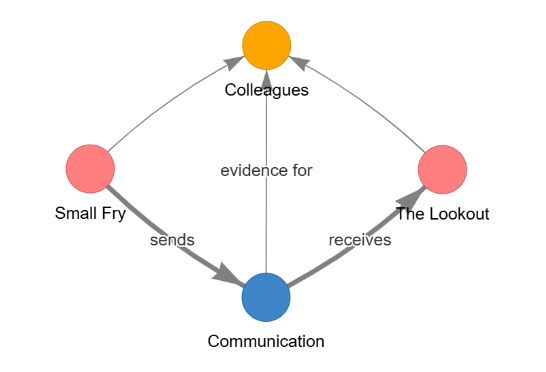

## Next steps

About graph
- Compute strong componets to findout communication networks

About sematics
- Compute similarity from messages to corruption and ilegal topics
- Then by clustering, identify which cluster correlates better with corruption topics.
- Add that a corruption label on the graph to map most interesing networks

About Visualization
- Add interactive exploration of topic similarities, enable a view of which patterns are most representative, and explicit textual content to link similarity with communication

About Timeline
- Repply communications timeline
- Message Analysis

### Implicit Relationships
- Facts are communications
- Relationships and events are subject to internal and Clepper biases during graph generation

Lets review events where the hot spot person `Nadie Conti`, sent or received messages tagged as Suspicious or AccessPermission.

In [ ]:
target_person = 'Nadia Conti'
target_relations = ['Suspicious', 'AccessPermission']
nodes_comm = []
suspicious_comm = []
count_bads = 0

for u, v in G.edges():
    if (target_person == v and 'Event' in u):
        uk = v; vk = u
    elif (target_person == u and 'Event' in v):
        uk = u; vk = v
    else: continue
    nodes_comm.append(vk)
    related_rel = [ui for ui in G.successors(vk) if map_nodes[G.nodes[ui]['label']] == 'Relationship' and G.nodes[ui]['sub_type'] in target_relations]
    if len(related_rel) > 0:
        print(f'{count_bads+1}')
        beauty_print(G.nodes[vk])
        suspicious_comm.append(G.nodes[vk])
        count_bads+=1
print(f'{count_bads}/{len(nodes_comm)}')

1
type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-05 09:45:00
content - Haacklee Harbor, this is Nadia Conti. I need to cancel the special access corridor arrangements for Nemo Reef immediately. Plans have changed due to unforeseen circumstances. Destroy all related documentation. I'll contact you when we're ready to proceed with alternative locations.


2
type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-08 08:18:00
content - Liam, Nadia here. Need your services urgently. Investigation brewing around Nemo Reef permits. Double your usual fee if you can ensure Harbor Master remains cooperative through next week. Meet at the usual place tomorrow, 10PM.


3
type - Event
sub_type - Communication
label - Communication
timestamp - 2040-10-05 09:44:00
content - Haacklee Harbor to Nadia Conti. Following your visit yesterday regarding the Nemo Reef event logistics, we've prepared the necessary documentation. Harbor staff is ready to 

## Text processing for insighful information

In [ ]:
import re
import pandas as pd
import spacy

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nlp = spacy.load("en_core_web_sm")

texts = [m["content"] for m in suspicious_comm]

df = pd.DataFrame({
    "text": texts
})


risk_terms = [
    "destroy documentation",
    "double your fee",
    "redirected attention",
    "suspects nothing",
    "clean up operations",
    "contingency",
    "ulterior motives",
    "special access",
    "closure",
    "payment",
    "permit",
    "cover",
    "security team",
    "facade",
    "protocols",
    "complications"
]

def risk_score(text):
    t = text.lower()
    score=0

    for term in risk_terms:
        if term in t:
            score +=2

    suspicious_patterns = [
        r"destroy.*documentation",
        r"double.*fee",
        r"bring payment",
        r"redirect.*attention",
        r"clean up operations"
    ]

    for p in suspicious_patterns:
        if re.search(p,t):
            score +=3

    return score


df["risk_score"] = df.text.apply(risk_score)

def extract_entities(text):
    doc = nlp(text)
    ents = [(e.text,e.label_) for e in doc.ents]
    return ents

df["entities"] = df.text.apply(extract_entities)
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=1
)


## Risk scoring by key pharses matching counting

In [ ]:
print("MOST SUSPICIOUS:")
print(df.sort_values("risk_score", ascending=False)[["risk_score", "text"]].head(10).to_string(max_colwidth=None))

MOST SUSPICIOUS:
   risk_score                                                                                                                                                                                                                                                                                                      text
3          10                                                                    Nadia, Liam here. Meeting confirmed for tomorrow at 10PM. I've redirected Harbor Master's attention and implemented new patrol schedules that work in our favor. Council suspects nothing about Nemo Reef. Bring payment as discussed.
6           7                                                                        Nadia, Liam here. EcoVigil is questioning the ROV delay. I've redirected them to the northern quadrant, but they're suspicious about the southwest. We need to clean up operations there immediately. What's our contingency plan?
8           6                                  

## Agents identification by linguistic analysis
We are lookin only for people, organizations or locations within messages

In [ ]:
entity_counter = Counter()

for ents in df.entities:
    for ent,label in ents:
        if label in ["PERSON","ORG","GPE"]:
            entity_counter[ent]+=1

print("\nFrequent entities")
for name, count_i in entity_counter.most_common(20):
    print(f'\t{name} - {count_i}')


Frequent entities
	Nadia - 8
	Nemo Reef - 5
	Liam - 3
	Haacklee Harbor - 2
	Nadia Conti - 2
	Davis - 2
	Harbor Master - 1
	Harbor Master's - 1
	Sam - 1
	V. Miesel's - 1
	City Council - 1
	Maritime Authority - 1
	EcoVigil - 1
	ROV - 1
	Mako - 1
	V. Miesel - 1
	Remora - 1


## Connecting entities by message

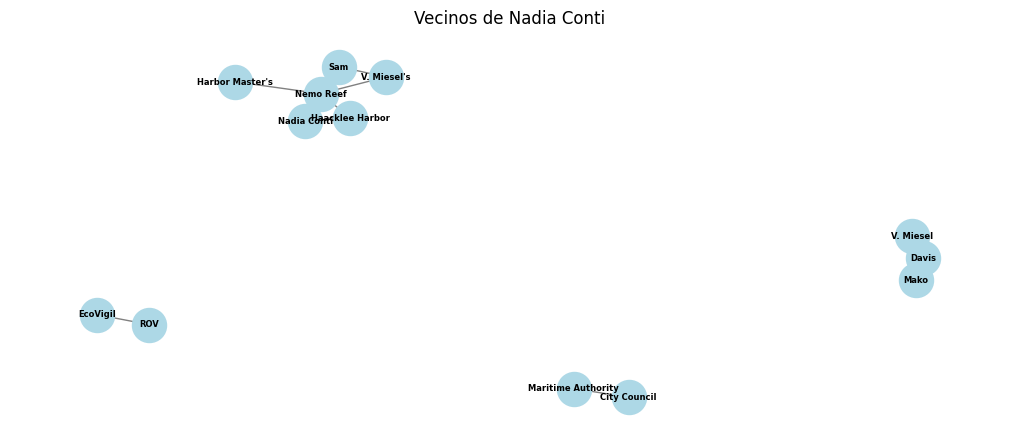

In [ ]:
import itertools

G_entities = nx.Graph()

for idx, ents in enumerate(df.entities):
    people = [
        e for e,l in ents
        if l in ["PERSON","ORG"]
    ]

    for a,b in itertools.combinations(set(people),2):
        if G_entities.has_edge(a,b):
            G_entities[a][b]["weight"]+=1
        else:
            G_entities.add_edge(a,b,weight=1)

pos = nx.spring_layout(G_entities, seed=42)

plt.figure(figsize=(10, 4))
nx.draw(G_entities, pos,
        with_labels=True,
        node_color="lightblue",
        node_size=600,
        font_size=6,
        font_weight="bold",
        edge_color="gray")
plt.title(f"Vecinos de {target_person}")
plt.axis("off")
plt.show()

## Topic analysis by word importance

In [ ]:
X = vectorizer.fit_transform(df.text)
terms = vectorizer.get_feature_names_out()
print('MESSAGES, words importance')
for i,row in enumerate(X):
    scores = zip(terms,row.toarray()[0])
    top = sorted(scores,key=lambda x:x[1],reverse=True)[:10]

    print("Message ",i+1)
    for k_i, i_r in top:
        print(f'\t{k_i}={i_r:.2f}')
    print('\n')


MESSAGES, words importance
Message  1
	alternative=0.15
	alternative locations=0.15
	arrangements nemo=0.15
	cancel=0.15
	cancel special=0.15
	changed=0.15
	changed unforeseen=0.15
	circumstances=0.15
	circumstances destroy=0.15
	contact=0.15


Message  2
	usual=0.31
	brewing=0.15
	brewing nemo=0.15
	cooperative=0.15
	cooperative week=0.15
	double=0.15
	double usual=0.15
	ensure=0.15
	ensure harbor=0.15
	fee=0.15


Message  3
	harbor=0.19
	arrangements discussed=0.15
	confirm=0.15
	confirm timeline=0.15
	conti following=0.15
	discussed confirm=0.15
	documentation harbor=0.15
	event=0.15
	event logistics=0.15
	facilitate=0.15


Message  4
	10pm ve=0.16
	attention=0.16
	attention implemented=0.16
	bring=0.16
	bring payment=0.16
	confirmed tomorrow=0.16
	council suspects=0.16
	favor=0.16
	favor council=0.16
	implemented=0.16


Message  5
	clarification=0.14
	clarification real=0.14
	concrete=0.14
	concrete forms=0.14
	confirmed nemo=0.14
	construction=0.14
	construction confirmed=0.14
	co

## Topic descomposition based on dirichlet ditribution

In [ ]:
lda = LatentDirichletAllocation(
    n_components=3,
    random_state=0
)

lda.fit(X)

print('TOPICS')
for i,topic in enumerate(lda.components_):
    words = [(terms[j], topic[j]) for j in topic.argsort()[-10:][::-1]]
    print(f"\nTopic {i}")
    for t_i, s_i in words:
        print(f"\tComponent {t_i} - Score {s_i:.3f}")


TOPICS

Topic 0
	Component meeting - Score 0.644
	Component 0600 - Score 0.612
	Component permit cr - Score 0.612
	Component tonight - Score 0.612
	Component cr 7844 - Score 0.612
	Component davis - Score 0.612
	Component cr - Score 0.612
	Component permit - Score 0.612
	Component 7844 - Score 0.612
	Component miesel - Score 0.598

Topic 1
	Component ve - Score 0.694
	Component harbor - Score 0.634
	Component redirected - Score 0.621
	Component nadia liam - Score 0.621
	Component ve redirected - Score 0.621
	Component discussed - Score 0.594
	Component liam - Score 0.587
	Component nadia - Score 0.513
	Component contingency - Score 0.511
	Component suspicious - Score 0.511

Topic 2
	Component usual - Score 0.641
	Component harbor - Score 0.536
	Component nemo reef - Score 0.521
	Component reef - Score 0.521
	Component nemo - Score 0.521
	Component nadia - Score 0.504
	Component need - Score 0.499
	Component circumstances - Score 0.487
	Component circumstances destroy - Score 0.487
	Com

In [ ]:
# !pip install vega_datasets
from vega_datasets import data
df = data.iris()
df.to_csv('iris_dataset.csv', index=False)